In this Jupyter notebook I want to write more or less a coherent, structured code that I would like to put into a package that will have all the TWPA code in it. This code will contain most of what has been finalized from the TWPA_Automation_Scripts and TWPA_Optmization_Code notebooks. I want to basically have one place where I have a working 'code/script' that I can use to just plug in data or something and run away. 

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import scienceplots
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator, RegularGridInterpolator
from scipy.optimize import differential_evolution
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import h5py
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import math
from scipy import integrate
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from whittaker_eilers import WhittakerSmoother
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image, ImageSequence
from scipy.spatial import cKDTree
from itertools import product
from numpy import load

plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({'font.size': 12})
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{siunitx}"
plt.rcParams["figure.figsize"] = (14, 7) 

The functions below are the helper functions that we need to pull data out from our files, they are used to get the parameter space data. 

In [2]:
def find_parameters(filename):
    """
    This function takes a file, specifically the hdf5 from which we get our data for the 
    TWPA and takes the specific parameters that we need to know for the optimization code. 
    Specifically, we want the values for the pump power, pump frequency and bias current, 
    and returns these values in a list respectively. 
    """
    file = h5py.File(filename, 'r')
    params_txt = (file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]).decode("utf-8")

    prev = None
    for i in params_txt.split("_"):
        if i.endswith('V'):
            bias_current = float(i[0:i.find('V')])
        elif i.endswith('GHz'):
            pump_freq = float(i[0:i.find('G')])
        elif i.endswith('dBm'):
            pump_power = float(prev)
        prev = i
        
    return [pump_power, pump_freq, bias_current]

def find_mean_ripple(filename, csv=False, start_band=4000000000.0, stop_band=8000000000.0, quantity_type=False):
    '''
    This function takes the filename, whether or not its a CSV, whether or not you want
    the mean or standard deviation of the gain ripples, and the bandwidth in which you
    want to calculate the quantity. This is one of the possible quantity choices that 
    you could take for optimization of the parameter space. It spits out the mean of 
    the gain ripple amplitudes, but could also return the standard deviation of the gain 
    ripple amplitudes 
    '''
    if (csv == False): 
        file = h5py.File(filename, 'r')
        freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs = np.linspace(freq_start, freq_stop, probe_pts)
        s21 = np.asarray(file['sweep_dataframe']).flatten()    
    else:
        df = pd.read_csv(filename, header=None)
        freqs = df[0].to_numpy()
        s21 = df[1].to_numpy()
        
    mask = (freqs >= start_band) & (freqs <= stop_band)
    freqs_window = freqs[mask]
    s21_window = s21[mask]
    
    # Applying the Savitzky-Golay Smoothing Function
    s21_sg = savgol_filter(s21_window, window_length=200, polyorder=2)
    
    peaks, _ = find_peaks(s21_window, prominence=0.0001)
    troughs, _ = find_peaks(-s21_window, prominence=0.0001)
        
    ripple_amplitudes = []
    for i in range(0, len(peaks)):
        ripple_amplitudes.append(s21_window[peaks[i]] - s21_sg[peaks[i]])
    
    for i in range(0, len(troughs)):
        ripple_amplitudes.append(s21_window[troughs[i]] - s21_sg[troughs[i]])
    
    if (quantity_type == True):
        return np.abs(np.std(ripple_amplitudes))
    else:
        return np.abs(np.mean(ripple_amplitudes))

def find_gain_quantity(filename_pumpon, filename_pumpoff, csv=False, start_band=4000000000.0, stop_band=8000000000.0):
    '''
    This function takes the filenames of the two main files, the pump on and pump off, 
    datasets and used them to calculate a quanitity which we are describing as the overall
    gain over a specific bandwidth specified by the start and stop bands. This 'gain'
    is the integral of the pump on minus the pump off datasets. 
    '''
    if (csv == False): 
        file_on = h5py.File(filename_pumpon, 'r')
        freq_start_on = file_on['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop_on = file_on['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts_on = file_on['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs_on = np.linspace(freq_start_on, freq_stop_on, probe_pts_on)
        s21_on = np.asarray(file_on['sweep_dataframe']).flatten()    
        
        file_off = h5py.File(filename_pumpoff, 'r')
        freq_start_off = file_off['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop_off = file_off['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts_off = file_off['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs_off = np.linspace(freq_start_off, freq_stop_off, probe_pts_off)
        s21_off = np.asarray(file_off['sweep_dataframe']).flatten()    
    else:
        df_on = pd.read_csv(filename_pumpon, header=None)
        freqs_on = df_on[0].to_numpy()
        s21_on = df_on[1].to_numpy()
        
        df_off = pd.read_csv(filename_pumpoff, header=None)
        freqs_off = df_off[0].to_numpy()
        s21_off = df_off[1].to_numpy()
        
    mask = (freqs_on >= start_band) & (freqs_on <= stop_band)
    freqs_on_window = freqs_on[mask]
    s21_on_window = s21_on[mask]
    freqs_off_window = freqs_off[mask]
    s21_off_window = s21_off[mask]
    
    gain = s21_on_window - s21_off_window 
    return integrate.simpson(gain, x=freqs_on_window)

def get_parameter_data(folder_path):
    '''
    This function takes the folder path in which all of the TWPA data files exist and sweeps
    through them for the correct type of file that we want (Magnitude/MLOG) and with the 
    pump on. It then uses the find_parameters and find_mean_ripple functions to calculate the 
    parameters for each file in the folder and append it to a list of the correct type. Then
    a list of np arrays of each of the parameters and the quantity is returned. 
    '''
    param_1 = []    ## Pump Power
    param_2 = []    ## Pump Frequency 
    param_3 = []    ## Bias Current
    quantity = []   ## Quantity (Gain Ripple Amplitude)
    
    folder_path = Path(folder_path)
    for f in folder_path.glob("*.hdf5"):
        file = h5py.File(f, 'r')
        pump_on = (file['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
        measurement = ((file['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))        
        if ((pump_on == True) and (measurement == 'MLOG')):
            pp, pf, bc = find_parameters(f)
            param_1.append(pp)
            param_2.append(pf)
            param_3.append(bc)
            quantity.append(find_mean_ripple(f))
    
    return [np.array(param_1), np.array(param_2), np.array(param_3), np.array(quantity)]

def get_parameter_data_gain(folder_path): 
    '''
    This function takes the folder path in which all of the TWPA data files exist and sweeps
    through them for the correct type of file that we want (Magnitude/MLOG) and with the 
    pump on. It then uses the find_parameters and find_mean_ripple functions to calculate the 
    parameters for each file in the folder and append it to a list of the correct type. Then
    a list of np arrays of each of the parameters and the quantity is returned. 
    '''
    param_1 = []    ## Pump Power
    param_2 = []    ## Pump Frequency 
    param_3 = []    ## Bias Current
    quantity = []   ## Quantity (Gain)
    
    folder_path = Path(folder_path)
    files = sorted(folder_path.glob("*.hdf5")) 
    for i, f in enumerate(files):
        file_on = h5py.File(f, 'r')
        pump_on = (file_on['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
        measurement = ((file_on['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))        
        if ((pump_on == False) and (measurement == 'MLOG')):
            if (i + 2) <= len(files):
                j = files[i+2]
                pp, pf, bc = find_parameters(f)
                param_1.append(pp)
                param_2.append(pf)
                param_3.append(bc)
                quantity.append(find_gain_quantity(j, f))
    
    return [np.array(param_1), np.array(param_2), np.array(param_3), np.array(quantity)]

def mls_interpolation(points, values, query_points, radius=0.5, poly_degree=1):
    """
    This function uses Moving Least Squares (MLS) interpolation.
    It finds the nearest neighbours within a radius and fits a 
    local polynomial (constant, linear, quadratic, or cubic)
    weighted by a Gaussian distance kernel.
    
    ---- Inputs ----
    points         :(N, 3) array of Sample Points (Data)
    values         :(N,) array of Function Values (Data)
    query_points   :(M, 3) array of query locations (Interpolated)
    radius         :Search radius for nearest neighbors
    poly_degree    :Degree of polynomial (0=const, 1=linear, 2=quad, 3=cubic)
    
    ---- Outputs ----
    Fq             :(M,) Returns the values of the interpolated points
    """
    tree = cKDTree(points)
    Fq = np.zeros(len(query_points))
    
    for i, q in enumerate(query_points):
        # find neighbors in radius
        idx = tree.query_ball_point(q, r=radius)
        if len(idx) == 0:
            Fq[i] = np.nan
            continue
        
        X = (points[idx] - q) / radius  # normalize local coordinates
        w = np.exp(-np.sum(X**2, axis=1) / radius**2)
        y = values[idx]

        # polynomial basis up to cubic
        if poly_degree == 0:
            A = np.ones((len(idx), 1))
        elif poly_degree == 1:
            A = np.column_stack([np.ones(len(idx)), X])
        elif poly_degree == 2:
            dx, dy, dz = X[:, 0], X[:, 1], X[:, 2]
            A = np.column_stack([np.ones(len(idx)), dx, dy, dz,
                                dx**2, dy**2, dz**2, dx*dy, dy*dz, dz*dx])
        elif poly_degree == 3:
            dx, dy, dz = X[:, 0], X[:, 1], X[:, 2]
            A = np.column_stack([
                np.ones(len(idx)), dx, dy, dz,
                dx**2, dy**2, dz**2, dx*dy, dy*dz, dz*dx,
                dx**3, dy**3, dz**3,
                dx**2*dy, dx**2*dz, dy**2*dx, dy**2*dz, dz**2*dx, dz**2*dy,
                dx*dy*dz
            ])
        else:
            raise NotImplementedError("Degree > 3 not supported")

        # Weighted least squares with regularization
        W = np.diag(w)
        Aw = W @ A
        yw = W @ y
        lambda_reg = 1e-4
        A_reg = np.vstack([Aw, np.sqrt(lambda_reg)*np.eye(A.shape[1])])
        y_reg = np.hstack([yw, np.zeros(A.shape[1])])
        coeffs, *_ = np.linalg.lstsq(A_reg, y_reg, rcond=None)
        

        # Evaluate at q (local coord = 0) → only the constant term remains
        Fq[i] = coeffs[0]
        Fq = np.clip(Fq, np.nanmin(values), np.nanmax(values))
    return Fq

def combine_gif_figure(gif1, gif2, output):
    '''
    This function just basically takes 2 gifs and plots them side by side to create and save another gif of this.
    '''
    # Paths to your two GIFs
    gif1_path = gif1
    gif2_path = gif2
    output_path = output

    # Open both GIFs
    gif1 = Image.open(gif1_path)
    gif2 = Image.open(gif2_path)

    # Ensure both have the same number of frames (optional but helpful)
    frames1 = [frame.copy() for frame in ImageSequence.Iterator(gif1)]
    frames2 = [frame.copy() for frame in ImageSequence.Iterator(gif2)]

    # If one is shorter, loop it
    if len(frames1) < len(frames2):
        frames1 *= len(frames2) // len(frames1)
    elif len(frames2) < len(frames1):
        frames2 *= len(frames1) // len(frames2)

    # Combine each pair of frames side by side
    combined_frames = []
    for f1, f2 in zip(frames1, frames2):
        # Ensure same height
        h = max(f1.height, f2.height)
        w = f1.width + f2.width
        new_frame = Image.new("RGBA", (w, h))
        new_frame.paste(f1, (0, 0))
        new_frame.paste(f2, (f1.width, 0))
        combined_frames.append(new_frame)

    # Save the combined frames as a single GIF
    combined_frames[0].save(
        output_path,
        save_all=True,
        append_images=combined_frames[1:],
        duration=gif1.info["duration"],  # Keep same speed
        loop=0,                          # Infinite loop
        disposal=2
    )
    print(f"✅ Combined GIF saved to {output_path}")


The functions below take the helper functions and basically do the plotting of the data and interpolated data. We have 3D scatter plotting, 3D volume plotting, and a script that will take slices in the interpolated data and combine them into a looping GIF of a 2D heatmap changing with constant parameter slices.

In [3]:
def scatter_plotter(x, y, z, f, grid_size):
    '''
    This function takes the parameter data that we had calculated earlier and applies 
    a MLS interpolater on it. Then we plot the interpolated data on a grid with size 
    N, in a 3D Scatter plot along with the original data. 
    '''
    ## Getting and Interpolating Data
    points = np.stack([x, y, z], axis=-1)
    Xq, Yq, Zq = np.meshgrid(
        np.linspace(min(x), max(x), grid_size),
        np.linspace(min(y), max(y), grid_size),
        np.linspace(min(z), max(z), grid_size),
        indexing="ij"
    )
    query_points = np.stack([Xq.ravel(), Yq.ravel(), Zq.ravel()], axis=-1)
    
    Fq = mls_interpolation(points, f, query_points, radius=0.5, poly_degree=1)
    
    ## Finding a Maximum in the dataset
    print("Any NaNs in f:", np.isnan(Fq).any())
    print("Count of NaNs:", np.isnan(Fq).sum())
    
    mask = ~np.isnan(Fq)
    f_valid = Fq[mask]
    points_valid = query_points[mask]

    idx_max = np.argmax(-f_valid)
    max_value = f_valid[idx_max]
    max_point = points_valid[idx_max]
    
    print(max_point, max_value)
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter3d(
        x=points_valid[:, 0], 
        y=points_valid[:, 1], 
        z=points_valid[:, 2], 
        mode="markers", 
        marker=dict(size=3, 
                    color=f_valid, 
                    cmin=0, 
                    cmax=1.8, 
                    colorbar=dict(title="Gain Ripples"),
                    opacity=0.5
        )
    ))
    fig.show()
    
    ## Plotting Real Original Data
    # fig = go.Figure()
    
    # # Plotting Interpolated Data
    # fig.add_trace(go.Scatter3d(
    #     x=query_points[:, 0],
    #     y=query_points[:, 1],
    #     z=query_points[:, 2],
    #     mode="markers",
    #     marker=dict(size=3, 
    #                 color=Fq, 
    #                 colorscale="inferno", 
    #                 cmin = 0, 
    #                 cmax = 2, 
    #                 colorbar=dict(title="Gain Ripples"), 
    #                 opacity=0.5),
    #     # name="MLS Interpolated"
    # ))
  
    # fig.update_layout(scene=dict(
    #     xaxis_title='Pump Power (dBm)', 
    #     yaxis_title='Pump Frequency (GHz)', 
    #     zaxis_title='Bias Current (mA)'
    # ))
    # fig.show()
    
    
    # fig = go.Figure()
    
    # # Original sparse points
    # fig.add_trace(go.Scatter3d(
    #     x=x, y=y, z=z,
    #     mode="markers",
    #     marker=dict(size=5, 
    #                 color=f, 
    #                 colorscale="inferno", 
    #                 cmin = 0, 
    #                 cmax = 2, 
    #                 colorbar=dict(title='Gain Ripples')),
    #     # name="Original Data"
    # ))
    
    # fig.update_layout(scene=dict(
    #     xaxis_title='Pump Power (dBm)', 
    #     yaxis_title='Pump Frequency (GHz)', 
    #     zaxis_title='Bias Current (mA)'
    # ))
    
    # fig.show()
    
    # return ()

def volume_plotter(x, y, z, f, isosurfaces, grid_size, radius=0.5, poly_degree=1):
    '''
    This function once again takes our parameter space data and applies an interpolater
    to it. However, instead of plotting a scatter plot we have to create a mesh grid
    on which the interpolater can be applied in order to create a volume plot. The 
    isosurfaces determine basically how many 'cuts' in the volume plot you want, more
    makes the volume plot more smoother in shape. 
    '''
    # Step 1: Prepare grid
    Xq, Yq, Zq = np.meshgrid(
        np.linspace(np.min(x), np.max(x), grid_size),
        np.linspace(np.min(y), np.max(y), grid_size),
        np.linspace(np.min(z), np.max(z), grid_size),
        indexing="ij"
    )
    query_points = np.stack([Xq.ravel(), Yq.ravel(), Zq.ravel()], axis=-1)

    # Step 2: Interpolate with MLS
    points = np.stack([x, y, z], axis=-1)
    Fq = mls_interpolation(points, f, query_points, radius=radius, poly_degree=poly_degree)
    Fq = np.array(Fq).reshape(Xq.shape)

    # Step 3: Handle NaNs or invalid values
    if np.all(np.isnan(Fq)):
        raise ValueError("All interpolated values are NaN — try increasing radius or lowering grid_size.")
    Fq = np.nan_to_num(Fq, nan=np.nanmean(Fq))

    # Determine visualization bounds
    fmin, fmax = np.percentile(Fq, [5, 95])  # avoid outliers

    # Step 4: Plot
    fig = go.Figure()

    # Volume rendering
    fig.add_trace(go.Volume(
        x=Xq.flatten(),
        y=Yq.flatten(),
        z=Zq.flatten(),
        value=Fq.flatten(),
        isomin=fmin,
        isomax=fmax,
        opacity=0.2,
        surface_count=15,
        colorscale='plasma',
        colorbar=dict(title='Interpolated Value')
    ))
    # Layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X Parameter',
            yaxis_title='Y Parameter',
            zaxis_title='Z Parameter'
        ),
        title='3D MLS Interpolated Volume'
    )

    fig.show()
    
def slice_heatmaps_mls(x, y, z, f, grid_size=100, radius=0.5, poly_degree=1):
    """
    Generates heatmap slices along each axis from 3D MLS-interpolated data.
    Saves each slice as a PNG and compiles them into GIFs for each parameter.

    --- Inputs ---
    x, y, z        : (N,) coordinate arrays
    f              : (N,) function values
    grid_size      : Number of points along each axis for interpolation
    radius         : Search radius for MLS neighbors
    poly_degree    : Polynomial degree for local MLS fit
    """

    # Create directories for frames if they don't exist
    os.makedirs("total_frames/pump_power_ripples", exist_ok=True)
    os.makedirs("total_frames/pump_frequency_ripples", exist_ok=True)
    os.makedirs("total_frames/bias_current_ripples", exist_ok=True)

    # Step 1: 3D Grid
    Xgrid = np.linspace(min(x), max(x), grid_size)
    Ygrid = np.linspace(min(y), max(y), grid_size)
    Zgrid = np.linspace(min(z), max(z), grid_size)
    X, Y, Z = np.meshgrid(Xgrid, Ygrid, Zgrid, indexing='ij')
    grid_points = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

    # Step 2: Interpolation using MLS
    points = np.stack([x, y, z], axis=-1)
    grid_values = mls_interpolation(points, f, grid_points, radius=radius, poly_degree=poly_degree)
    grid_values = grid_values.reshape((grid_size, grid_size, grid_size))

    # Step 3: Create slices along each axis
    for i in range(grid_size):
        # Pump Power slices
        slice_pp = grid_values[i, :, :]
        fig = go.Figure(data=go.Heatmap(
            x=Y[0, :, 0],
            y=Z[0, 0, :],
            z=slice_pp.T,
            colorscale='inferno', 
            zmin = 0, 
            zmax = 2, 
            colorbar=dict(title='Gain Ripples (dB)')
        ))
        fig.update_layout(
            title=f"Slice at Pump Power = {X[i,0,0]:.2f} dBm",
            xaxis_title="Pump Frequency",
            yaxis_title="Bias Current"
        )
        fig.write_image(f"total_frames/pump_power_ripples/frame_{i:03d}.png")

        # Pump Frequency slices
        slice_pf = grid_values[:, i, :]
        fig = go.Figure(data=go.Heatmap(
            x=X[:, 0, 0],
            y=Z[0, 0, :],
            z=slice_pf.T,
            colorscale='inferno', 
            zmin = 0, 
            zmax = 2, 
            colorbar=dict(title='Gain Ripples (dB)')
        ))
        fig.update_layout(
            title=f"Slice at Pump Frequency = {Y[0,i,0]:.3f} GHz",
            xaxis_title="Pump Power",
            yaxis_title="Bias Current"
        )
        fig.write_image(f"total_frames/pump_frequency_ripples/frame_{i:03d}.png")

        # Bias Current slices
        slice_bc = grid_values[:, :, i]
        fig = go.Figure(data=go.Heatmap(
            x=X[:, 0, 0],
            y=Y[0, :, 0],
            z=slice_bc.T,
            colorscale='inferno',
            zmin = 0, 
            zmax = 2, 
            colorbar=dict(title='Gain Ripples (dB)')
        ))
        fig.update_layout(
            title=f"Slice at Bias Current = {Z[0,0,i]:.2f} mA",
            xaxis_title="Pump Power",
            yaxis_title="Pump Frequency"
        )
        fig.write_image(f"total_frames/bias_current_ripples/frame_{i:02d}.png")

    # Step 4: Compile GIFs
    for param, folder, outname, duration in [
        ("Pump Power", "total_frames/pump_power_ripples", "Pump_Power_Sweep_Ripples.gif", 300),
        ("Pump Frequency", "total_frames/pump_frequency_ripples", "Pump_Frequency_Sweep_Ripples.gif", 100),
        ("Bias Current", "total_frames/bias_current_ripples", "Bias_Current_Sweep_Ripples.gif", 200)
    ]:
        frames = [Image.open(os.path.join(folder, f))
                  for f in sorted(os.listdir(folder)) if f.endswith(".png")]
        if frames:
            frames[0].save(outname,
                           save_all=True,
                           append_images=frames[1:],
                           duration=duration,
                           loop=0)

In [22]:
def get_pareto_data(folder_path): 
    param_1 = []    ## Pump Power
    param_2 = []    ## Pump Frequency 
    param_3 = []    ## Bias Current
    quantity1 = []   ## Quantity (Gain)
    quantity2 = []   ## Quantity (Gain Ripples)
    
    folder_path = Path(folder_path)
    files = sorted(folder_path.glob("*.hdf5")) 
    for i, f in enumerate(files):
        file_on = h5py.File(f, 'r')
        pump_on = (file_on['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
        measurement = ((file_on['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))        
        if ((pump_on == False) and (measurement == 'MLOG')):
            if (i + 2) <= len(files):
                j = files[i+2]
                pp, pf, bc = find_parameters(f)
                param_1.append(pp)
                param_2.append(pf)
                param_3.append(bc)
                quantity2.append(find_mean_ripple(j))
                quantity1.append(find_gain_quantity(j, f))
    
    return [np.array(param_1), np.array(param_2), np.array(param_3), np.array(quantity1), np.array(quantity2)]

In [23]:
pump_power, pump_frequency, bias_current, gain, gain_ripples = get_pareto_data('full_july_data')

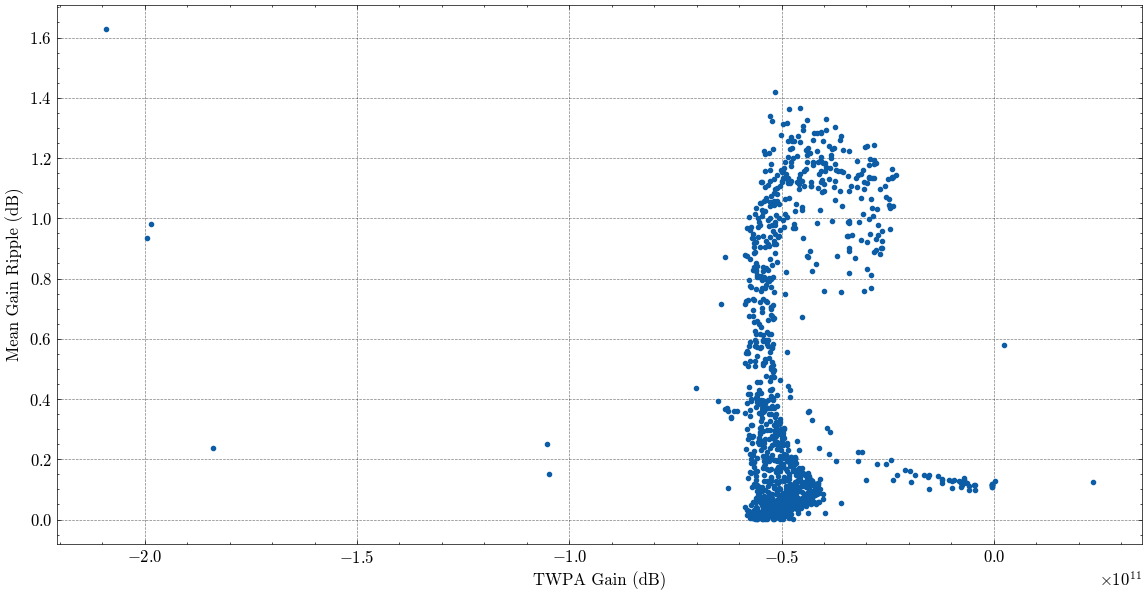

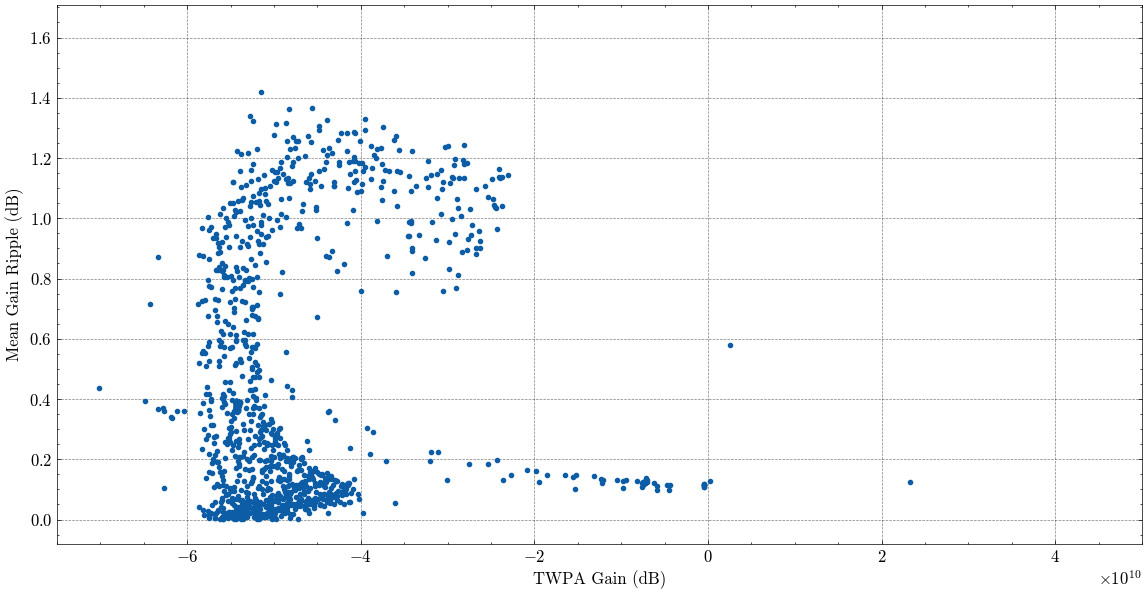

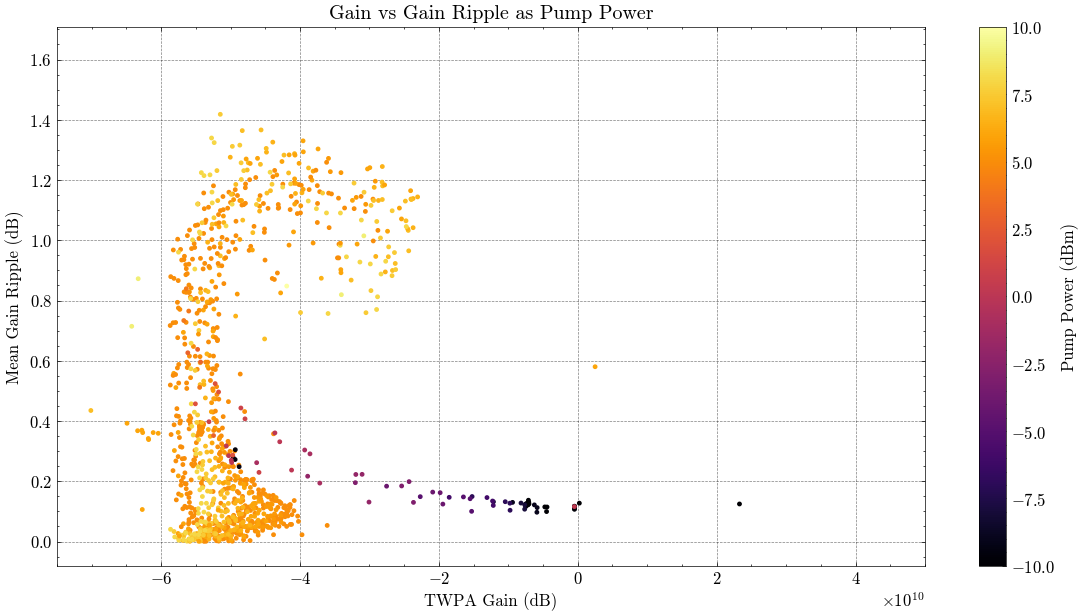

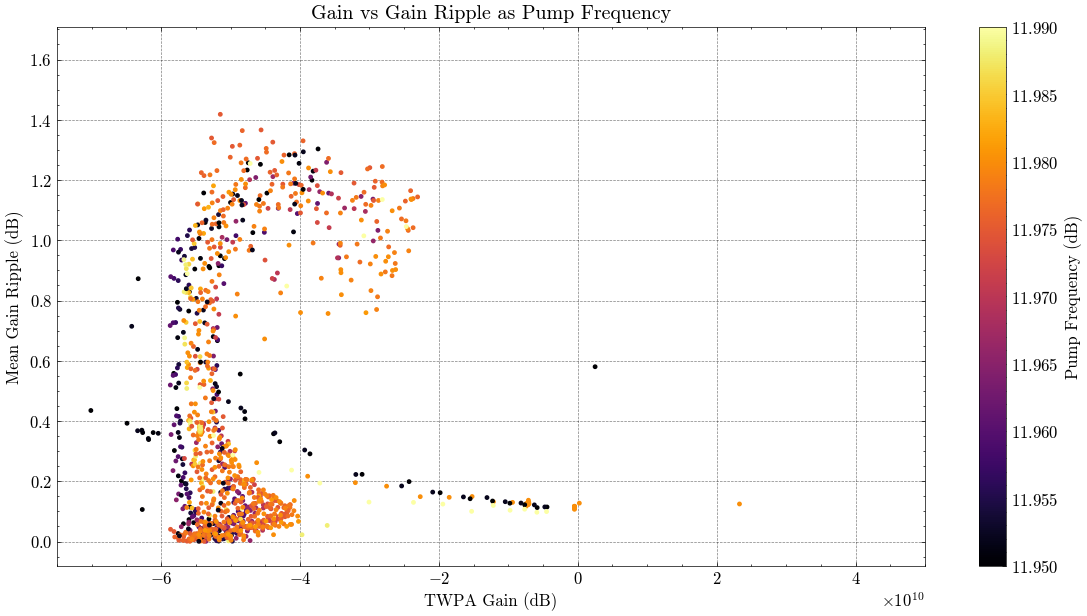

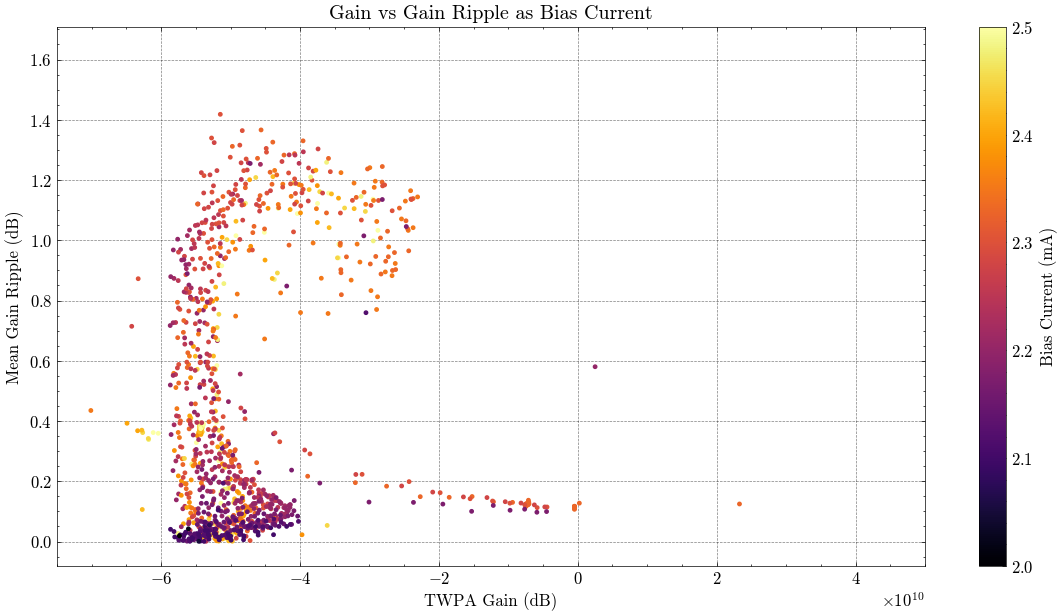

In [34]:
plt.plot(gain, gain_ripples, '.')
plt.xlabel("TWPA Gain (dB)")
plt.ylabel("Mean Gain Ripple (dB)")
# plt.gca().invert_yaxis() 
plt.show()

plt.plot(gain, gain_ripples, '.')
plt.xlabel("TWPA Gain (dB)")
plt.ylabel("Mean Gain Ripple (dB)")
# plt.gca().invert_yaxis() 
plt.xlim(-0.75e11, 0.5e11)
plt.show()

sc = plt.scatter(gain, gain_ripples, c=pump_power, cmap='inferno', s=6)  
plt.colorbar(sc, label='Pump Power (dBm)')
plt.xlabel('TWPA Gain (dB)')
plt.ylabel('Mean Gain Ripple (dB)')
plt.xlim(-0.75e11, 0.5e11)
plt.title("Gain vs Gain Ripple as Pump Power")
plt.show()

sc = plt.scatter(gain, gain_ripples, c=pump_frequency, cmap='inferno', s=6)  
plt.colorbar(sc, label='Pump Frequency (dB)')
plt.xlabel('TWPA Gain (dB)')
plt.ylabel('Mean Gain Ripple (dB)')
plt.xlim(-0.75e11, 0.5e11)
plt.title("Gain vs Gain Ripple as Pump Frequency")
plt.show()

sc = plt.scatter(gain, gain_ripples, c=bias_current, cmap='inferno', s=6)  
plt.colorbar(sc, label='Bias Current (mA)')
plt.xlabel('TWPA Gain (dB)')
plt.ylabel('Mean Gain Ripple (dB)')
plt.xlim(-0.75e11, 0.5e11)
plt.title("Gain vs Gain Ripple as Bias Current")
plt.show()

In [7]:
# scatter_plotter(pump_power, pump_frequency, bias_current, gain_ripples, 25)

The next few cells will discuss the other stuff that you can do with the TWPA data, namely the time domain reflectometry code that was developed to sort of see the impedence of the TWPA as we go along the line, as well as the fitting and figuring out of I* which is the scaling current that can be found. Eventually this package should also include the code that was worked on to create the defect detection in the TWPA line from the images that Ahmet and Rubayet provided me with. (If I can ever get the defect detection to work properly.)

In [6]:
## This is the Time Domain Reflectometry Code

def get_data_tdr(filename_mag, filename_phase, csv=True, start_band=0, stop_band=1.8e10):
    '''
    This function takes the files necessary to get data that is usable for the time 
    domain reflectometry (TDR) block of code. It provides a start and stop band as 
    well such that the user can choose what frequencies want to be looked at. 
    
    --- Inputs ---
    filename_mag            : Filename of the MLOG Data
    filename_phase          : Filename of the PHAS Data
    csv                     : True, if false then dealing with hdf5 files
    start_band              : 0 GHz, starting frequency of data
    stop_band               : 18 GHz, stopping frequency of data
    
    --- Outputs ---
    Returns a list of 3 np.arrays that contain the Frequency, Magnitude, and Phase data
    respectively of the files that were provided. 
    '''
    if (csv == False): 
        file = h5py.File(filename_mag, 'r')
        freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs = np.linspace(freq_start, freq_stop, probe_pts)
        mag = np.asarray(file['sweep_dataframe']).flatten() 
        
        filep = h5py.File(filename_phase, 'r')
        phase = np.asarray(file['sweep_dataframe']).flatten()        
        
        mask = (freqs >= start_band) & (freqs <= stop_band)
        freqs_window = freqs[mask]
        mag_window = mag[mask]  
        phase_window = phase[mask] 
        return [freqs_window, mag_window, phase_window]
    else: 
        df = pl.read_csv(filename_mag)    
        dfp = pl.read_csv(filename_phase)
        mask = (df[df.columns[0]].to_numpy() >= start_band) & (df[df.columns[0]].to_numpy() <= stop_band)
        return [((df[df.columns[0]]).to_numpy())[mask], ((df[df.columns[1]]).to_numpy())[mask], ((dfp[dfp.columns[1]]).to_numpy())[mask]]
    
def perform_ifft_tdr(freq, mag, phase, ifft_return=False, plot=False):
    '''
    This function performs and inverse fourier transform on the data provided. 
    It can return the arrays containing the time and time domain data of the 
    ifft as well as potentially plot it as well. 
    
    --- Inputs --- 
    freq                : Frequency data, np.array
    mag                 : MLOG/Magnitude data, np.array
    phase               : PHAS/Phase data, np.array
    ifft_return         : False, if True returns time domain data
    plot                : False, if True plots the IFFT 
    
    --- Outputs --- 
    Returns a list of 2 np.arrays time and full_magdata_time, which are the 
    time (x-axis) values and the time domain magnitude (y-axis) data.     
    '''
    phase = np.pi/180 * phase
    full_magdata = 10**(mag/20) *np.exp(1j*phase)

    full_magdata_time = ifft(full_magdata)
    
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    if plot == True:            
        plt.plot(time, full_magdata_time, label='Data')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.title('Inverse Fourier Transform')
        plt.legend()
        plt.show()

    if ifft_return == True:
        return [time, full_magdata_time]
    
def get_impedence_plot(freq, mag, phase, xlim_low=0, xlim_high=5, limit=False):
    ## The first step is to convert the S11 Magnitude and Phase data into a complex version that is basically 
    ## our reflection coefficient which is needed to do all of this. The reflection coefficient is however
    ## not in dB, so it's on a linear scale so converting to that shouldn't be too hard at all. 
    
    phase = np.pi/180 * phase ## Converting Phase from Degrees to Radians 
    gamma_freq = 10**(mag/20) * np.exp(1j*phase) ## Reflection Coefficient in Frequency Domain
    
    gamma_time = ifft(gamma_freq)   ## Perform the IFFT to get to time domain
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    impedence = 50 * ((1 + gamma_time)/(1 - gamma_time))  ## Calculate the Impedence with the formula 
    distance = 0.8*3e8*time/2  ## Calculate the distance travelled based on the velocity of light inside the cable + time data
    filtered = savgol_filter(impedence, window_length=15, polyorder=2)

    plt.plot(distance, impedence, label='Raw Data')
    # plt.plot(distance, filtered, label='Smoothed Data', color='firebrick')
    plt.xlabel('Distance (m)')
    plt.ylabel('Impedence (Ohms)')
    plt.title('Impedence vs Distance')
    plt.legend()
    if limit==True:
        plt.xlim(xlim_low, xlim_high)
    plt.show()    
    
def get_impedence_tdr(freqs, mag, phase):
    '''
    This function takes our frequency, MLOG and PHAS data of a certain file, 
    and converts it into distance and impedence values for the scan. 
    
    --- Inputs --- 
    freqs           : Frequency data, np.array
    mag             : MLOG/Magnitude data, np.array
    phase           : PHAS/Phase data, np.array 
    
    --- Outputs --- 
    Returns a list of the distance and impedence np.arrays respectively
    '''
    phase = np.pi/180 * phase 
    gamma_freq = 10**(mag/20) * np.exp(1j*phase)
    
    gamma_time = ifft(gamma_freq)
    N = len(freqs)
    df = freqs[1] - freqs[0]
    dt = 1 / (N*df)
    
    time = np.arange(N) * dt
    
    impedence = 50 * ((1 + gamma_time)/(1 - gamma_time))
    distance = 0.8*3e8*time/2
    
    return [distance, impedence]
    
def impedence_statistics(distance, impedence, threshold, plot=False):
    '''
    This function takes the distance and impedence arrays calculated to create a plot
    of the landscape. It also takes a threshold above which some impedence mismatches
    should be highlighted and plotted. 
    
    --- Inputs --- 
    distances               : The distance values in the impedence landscape
    impedence               : The impedence values in the impedence landscape
    threshold               : The impedence threshold (above/below 50 Ohms) at which a mismatch is to be identified
    plot                    : False, if True plots the Distance vs Impedence graph
    
    --- Outputs --- 
    Returns a list of the disatncess and impedencess of the mismatches
    that have been identified based on the threshold respectively. 
    
    '''
    peaks, _ = find_peaks(impedence, height = 50 + threshold)
    troughs, _ = find_peaks(-impedence, height = -(50 - threshold))
    
    distancess = [distance[peaks], distance[troughs]]
    impedencess = [np.abs(impedence[peaks]), np.abs(impedence[troughs])]
    
    if plot == True: 
        plt.plot(distance, impedence, label='Impedence Landscape')
        plt.plot(distance[peaks], impedence[peaks], 'o', markersize=2.5, color='firebrick', label='Potential Mismatch Locations')
        plt.plot(distance[troughs], impedence[troughs], 'o', markersize=2.5, color='firebrick')
        plt.xlabel('Distance (m)')
        plt.ylabel('Impedence (Ohms)')
        plt.title('Impedence vs Distance')
        plt.legend()
        plt.show()   
        
    return [distancess, impedencess]

def twpa_impedences(folder_name, mismatch_threshold): 
    '''
    This function takes the folder which contains all of the TWPA measurement files as
    well as a mismatch threshold value and uses it to find the impedence plots for all 
    of the files within the folder. It counts the number of these 'mismatches', their
    respective impedences and the distance through which they ocurr within the line to 
    spit out histograms that portray this data. 
    
    --- Inputs --- 
    folder_name         : Folder in which the data files are kept
    mismatch_threshold  : The impedence threshold (above/below 50 Ohms) at which a mismatch is to be identified
    '''
    distances_total = []
    impedences_total = []
    
    folder_path = Path(folder_name)
    files = sorted(folder_path.glob("*.hdf5"))
    for i, f in enumerate(files):
        file_on = h5py.File(f, 'r')
        pump_on  = (file_on['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
        measurement = ((file_on['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))        
        if ((pump_on == True) and (measurement == 'MLOG')):
            if (i + 2) <= len(files):
                j = files[i+1]
                freq, mag, phase = get_data_tdr(f, j, csv=False, start_band=4e9, stop_band=8e9)
                distance, impedence = get_impedence_tdr(freq, mag, phase)
                distances, impedences = impedence_statistics(distance, impedence, mismatch_threshold)
                distances_total = distances_total + distances 
                impedences_total = impedences_total + impedences
            
    mismatch_distances = []
    mismatch_impedences = []
    mismatch_impedences_absolute = []
    for i in distances_total:
        for j in i:
            mismatch_distances.append(j)
    for i in impedences_total:
        for j in i:
            mismatch_impedences.append(j)
            mismatch_impedences_absolute.append(np.abs(50-j))
            
    plt.hist(mismatch_distances, bins=30, density=True)
    plt.title('Distance to Potential Impedence Mismatch')
    plt.xlabel('Distance (m)')
    plt.ylabel('Normalized Counts')
    plt.show()

    plt.hist(mismatch_impedences, bins=25, density=True)
    plt.title('Impedences of Mismatch Points')
    plt.xlabel('Impedence (Ohms)')
    plt.ylabel('Normalized Counts')
    plt.show()

    plt.hist(mismatch_impedences_absolute, bins=20)
    plt.title('Absolute Impedences of Mismatch Points')
    plt.xlabel('Impedence (Ohms)')
    plt.ylabel('Counts')
    plt.show()
 
## This is the Scaling Current Code   

def m_to_istar(m):
    return np.sqrt(1/m)

def quadratic_fit(x, a):
    return a*x**2

def istar_expression(file_dep, file_zero, frequency_band, file_dispersion):
    '''
    This function essentially does the backbone of the expression calculation for 
    fitting I_star. It gets the data that is given to convert it to the correct
    'x' and 'y' values that will be used in the quadratic fitting for I_star later
    on. For further explaination of the fitting check the documentation. 
    
    --- Inputs --- 
    file_dep               : This is the file from which the bias current 
                             dependent phase values are extracted
                             
    file_zero              : This is the file from which the zero-bias current 
                             phase values are extracted
                             
    frequency_band         : This is the frequency at which you want to calculate I_star
    
    file_dispersion        : This is the dispersion plots from Milad that are used 
                             to calculate the time of flight of the light inside the TWPA
    
    --- Outputs --- 
    A list of the x and y values are returned. The x value is the 
    bias current value (mA) and the y value is the other side of the 
    equation used to calculate I_star, basically the total phase change. 
    '''
    ## Important Values
    N_sc = 320.0
    L_sc = (35.0*15.0)/10**6

    ## Speed of Light and Traversal Time Calculations 
    data = load(file_dispersion)
    lst = data.files

    frequency_twpa = data[lst[0]]
    k_vector = data[lst[1]]/L_sc  
    omega = 2*np.pi*frequency_twpa*1e9 
    
    phase_velocity = (omega/k_vector)
    tau_twpa = (N_sc*L_sc)/phase_velocity 
    
    ## Original bias-current dependent file
    file = h5py.File(file_dep, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    phase = np.asarray(file['sweep_dataframe']).flatten() 
        
    params_txt = (file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]).decode("utf-8")

    for i in params_txt.split("_"):
        if i.endswith('V'):
            bias_current = float(i[0:i.find('V')])
    
    ## Zero bias-current file 
    file_naught = h5py.File(file_zero, 'r')
    phase_naught = np.asarray(file_naught['sweep_dataframe']).flatten() 
    
    phase = phase * (np.pi/180)
    phase_naught = phase_naught * (np.pi/180)
    
    ## Relative phase
    indices_phase = np.where(freqs >= frequency_band)
    indices_twpa = np.where(frequency_twpa*1e9 >= frequency_band)
    index_phase = indices_phase[0][0]
    index_twpa = indices_twpa[0][0]
    
    theta_I = phase[index_phase]
    theta_0 = phase_naught[index_phase]
    theta_r = 2*np.pi*frequency_band*tau_twpa[index_twpa]
    
    ## Expression buildup 
    x = bias_current
    y = -2*((theta_I-theta_0)/(theta_r))
    
    return [x, y]

def calculating_istar(folder_name, frequency_band, file_zero, file_dispersion, plot=False):
    '''
    This function takes the entire folder in which the phase data is kept and employs
    the 'istar_expression' function to calculate i_stars for a certain frequency. The 
    fit can only be performed if we fix a frequency, check the documentation for more
    information on why this is. 
    
    --- Inputs ---
    folder_name         :
    frequency_band      :
    file_zero           :
    file_dispersion     :
    plot                :
    
    --- Outputs --- 
    A list of the corresponding I_star fit and the respective error on the fit.
    '''
    
    dc_currents = []
    delta_thetas = []
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.hdf5"):
        x, y = istar_expression(f,
                                file_zero, 
                                frequency_band, 
                                file_dispersion)
        dc_currents.append(x)
        delta_thetas.append(y)
        
    dc_currents = np.array(dc_currents)
    delta_thetas = np.array(delta_thetas)
            
    param, cov = curve_fit(quadratic_fit, dc_currents, delta_thetas)
    perr = np.sqrt(np.diag(cov))
    m_fit = param
    m_fit_error = perr
    
    if plot == True:   
        fitted_y = quadratic_fit(dc_currents, m_fit)
        
        plt.plot(dc_currents, delta_thetas, 'o', label='Raw Data')
        plt.plot(dc_currents, fitted_y, label='Linear Fit')
        plt.xlabel(r'$I_{dc}$' + " (mA)")
        plt.ylabel(r'$-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}$')
        plt.legend()
        plt.show()
        
    return [m_to_istar(m_fit), m_to_istar(m_fit_error)] 